<a href="https://colab.research.google.com/github/vignesh-codes/ECE9063-Assignment-1/blob/main/unsupervised_k_means_not_working.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('train.csv')
df = df.iloc[:25000]
# Convert the 'date' column to datetime format
# df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df['date'] = pd.to_datetime(df['date'])
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

# Extract useful features from the date
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

# Add lag features (e.g., sales from the previous day, week, and 12 months ago)
df['lag_1'] = df['sales'].shift(1)  # Previous day's sales
df['lag_7'] = df['sales'].shift(7)  # Previous week's sales
df['lag_365'] = df['sales'].shift(365)  # Previous year's sales (seasonality)

# Add rolling mean (7-day and 30-day rolling averages)
df['rolling_mean_7'] = df['sales'].rolling(window=7).mean()
df['rolling_mean_30'] = df['sales'].rolling(window=30).mean()

# Drop any rows with missing values (due to lag and rolling operations)
df = df.dropna()
# sort the data by timestamp
df = df.sort_values(by='date')
df.head(10)

,date,store,item,sales,day,month,year,lag_1,lag_7,lag_365,rolling_mean_7,rolling_mean_30
14608,2013-01-01,9,1,11,1,1,2013,26.0,17.0,32.0,23.000000,22.666667
10956,2013-01-01,7,1,7,1,1,2013,19.0,10.0,18.0,12.571429,13.366667
16434,2013-01-01,10,1,14,1,1,2013,19.0,14.0,16.0,18.857143,19.133333
21912,2013-01-01,3,2,43,1,1,2013,79.0,57.0,65.0,65.714286,62.700000
9130,2013-01-01,6,1,20,1,1,2013,24.0,17.0,11.0,17.285714,15.066667
7304,2013-01-01,5,1,11,1,1,2013,23.0,16.0,16.0,20.285714,20.033333
18260,2013-01-01,1,2,33,1,1,2013,27.0,10.0,25.0,22.285714,20.500000
3652,2013-01-01,3,1,19,1,1,2013,31.0,18.0,33.0,22.428571,22.133333
1826,2013-01-01,2,1,12,1,1,2013,23.0,13.0,19.0,18.000000,17.000000
20086,2013-01-01,2,2,41,1,1,2013,67.0,37.0,40.0,51.714286,46.533333


In [12]:
from sklearn.preprocessing import StandardScaler

# 2. Define the Features for Clustering
X = df[['day', 'month', 'year', 'lag_1', 'lag_7', 'lag_365', 'rolling_mean_7', 'rolling_mean_30']]

# Standardize the features since K-Means is sensitive to feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [18]:
from sklearn.cluster import KMeans

# 3. Apply K-Means Clustering
n_clusters = 5  # You can adjust the number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [19]:
from sklearn.metrics import silhouette_score


# Calculate the silhouette score
silhouette_avg = silhouette_score(X_scaled, df['cluster'])
print(f'Silhouette Score: {silhouette_avg}')

Silhouette Score: 0.2040165697227609


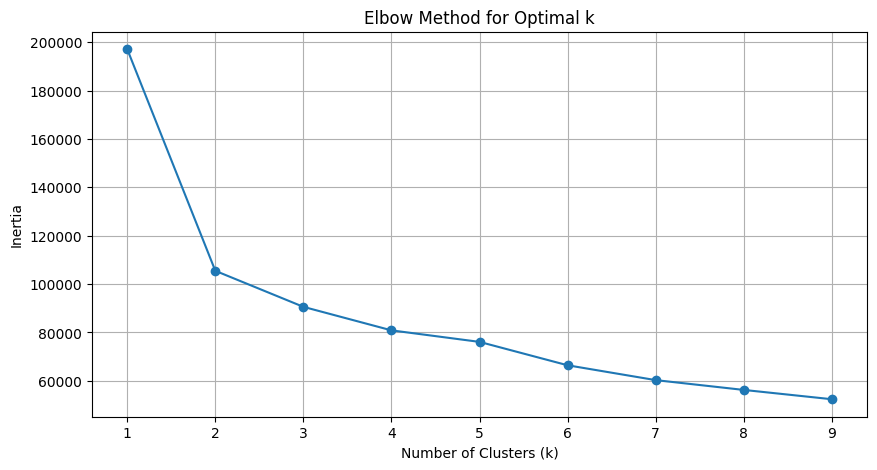

In [20]:
inertia = []
k_range = range(1, 10)  # Adjust range for more clusters if needed

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plotting the elbow curve
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

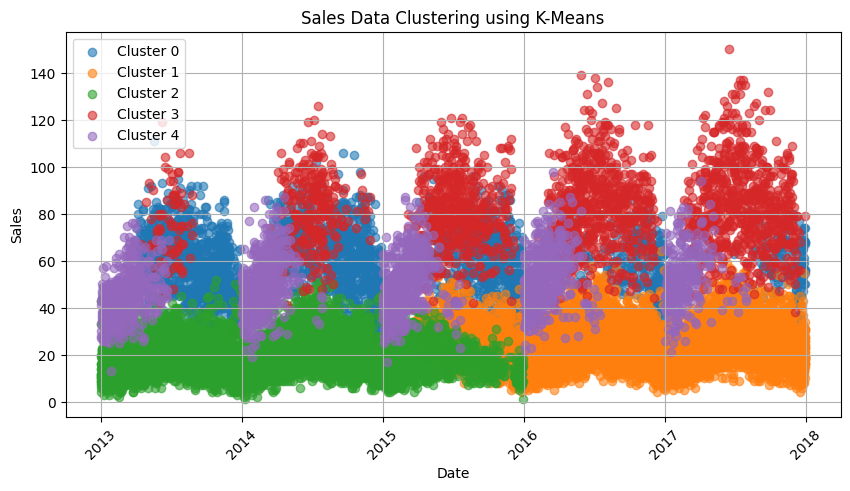

In [21]:
# 4. Visualization
plt.figure(figsize=(10, 5))

# Plot each cluster with different colors
for cluster in range(n_clusters):
    plt.scatter(df[df['cluster'] == cluster]['date'],
                df[df['cluster'] == cluster]['sales'],
                label=f'Cluster {cluster}',
                alpha=0.6)

plt.title('Sales Data Clustering using K-Means')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True)
plt.show()

DatetimeIndex(['2018-01-01', '2018-01-02', '2018-01-03', '2018-01-04',
               '2018-01-05', '2018-01-06', '2018-01-07', '2018-01-08',
               '2018-01-09', '2018-01-10',
               ...
               '2024-10-26', '2024-10-27', '2024-10-28', '2024-10-29',
               '2024-10-30', '2024-10-31', '2024-11-01', '2024-11-02',
               '2024-11-03', '2024-11-04'],
              dtype='datetime64[ns]', length=2500, freq='D')
[26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 

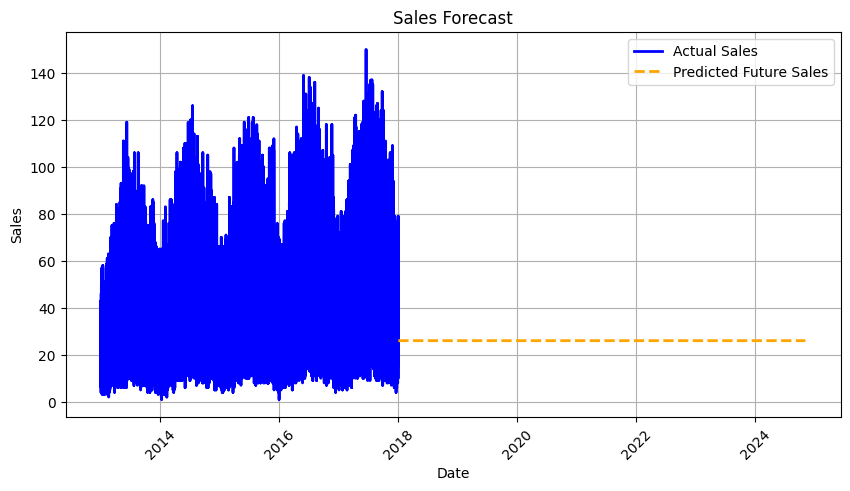

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming you already have your historical sales data in 'df'
# and that 'sales' is your sales column

# Step 1: Generate Future Sales Predictions
# Let's say you want to predict the next 10 days of sales

forecast_steps = 2500
last_known_sales = df['sales'].iloc[-1]  # Use the last known sales as a simple predictor
future_sales = [last_known_sales] * forecast_steps  # A simple approach (can be improved)

# Step 2: Create a Date Range for Future Predictions
last_date = df['date'].iloc[-1]  # Get the last date from the historical data
forecast_index = pd.date_range(start=last_date + pd.Timedelta(days=1),
                                periods=forecast_steps,
                                freq='D')
print(forecast_index)
print(future_sales)

# Create a DataFrame for future sales
future_sales_df = pd.DataFrame({'date': forecast_index, 'predicted_sales': future_sales})

# Step 3: Plot Historical and Future Sales
plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['sales'], label='Actual Sales', color='blue', linewidth=2)  # Historical sales
plt.plot(future_sales_df['date'], future_sales_df['predicted_sales'], label='Predicted Future Sales', color='orange', linestyle='--', linewidth=2)  # Future sales

plt.title('Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True)
plt.show()
